# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Adinda Nur Isnaini
- **Email:** adindanurisnaini159@gmail.com
- **ID Dicoding:** CDCC008D6X2718

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren penyewaan sepeda secara harian selama periode 2011–2012?
- **Pertanyaan 2:** Pada bulan apa terjadi puncak penyewaan sepeda dan bagaimana pola musiman selama periode 2011–2012?
- **Pertanyaan 3:** Bagaimana perbedaan pola penyewaan pada waktu tertentu dalam sehari?
- **Pertanyaan 4:** Berapa perbedaan rata-rata jumlah penyewaan sepeda pada setiap kondisi cuaca dan faktor lingkungan (suhu, kelembapan, dan kecepatan angin) selama periode 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import zipfile
import requests
import io
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df day & hour

In [2]:
# download zip
url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
r = requests.get(url)

# extract
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

# load data
day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")

**Insight:**

Langkah pertama untuk analisis data adalah *Gathering Data* atau mengumpulkan dataset.
Dataset yang digunakan bernama *Bike Sharing Dataset* yang memiliki format *.zip*. Untuk untuk data di dalamnya, dilakukan ekstraksi file format *.zip* menggunakan fungsi `zipfile.Zipfile()`.

Setelah melakukan ekstraksi, didapatkan dua *file* yang digunakan untuk analisis, yaitu *day.csv* dan *hour.csv*. Kedua *file* tersebut disimpan ke dalam *DataFrame* dengan nama `day` dan `hour`.

### Assessing Data

**Steps to Take:**
- Identifikasi struktur data melalui `info()`
- Identifikasi rentang waktu pada data
- Identifikasi *missing timestamp*
- Identifikasi *missing value*
- Identifikasi data duplikat

#### Identifying data information

In [3]:
day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Berdasarkan *output*, dapat diketahui bahwa kedua *dataframe* memiliki fitur yang hampir sama. Perbedaan utama terdapat pada keberadaan fitur `hr` pada `hour`. Hal ini disebabkan oleh perbedaan tingkat agregasi data. *Dataframe* `day` menyajikan informasi penyewaan sepeda dalam skala harian, sedangkan, sedangkan `hour` menyajikan data dalam skala per jam sehingga memberikan informasi yang lebih rinci.

#### Identifying time range

In [5]:
# Ubah fitur tanggal ke format datetime
day['datetime'] = pd.to_datetime(day['dteday'])
hour['datetime'] = pd.to_datetime(hour['dteday'])

# Periksa rentang tanggal pada kedua dataset
print(day['dteday'].min(), day['dteday'].max())
print(hour['dteday'].min(), hour['dteday'].max())

2011-01-01 2012-12-31
2011-01-01 2012-12-31


Langkah selanjutnya adalah mengidentifikasi rentang waktu pada kedua *dataframe*. *Output* di atas menunjukkan bahwa rentang waktu kedua *dataframe* tersebut sama, yaitu 1 Januari 2011 hingga 31 Desember 2012 atau 2 tahun penuh.

In [6]:
# ubah ke datetime
hour['datetime'] = pd.to_datetime(hour['dteday']) + pd.to_timedelta(hour['hr'], unit='h')

# cek range waktu
print(hour['datetime'].min(), hour['datetime'].max())

# expected full range
full_range = pd.date_range(start=hour['datetime'].min(),
                           end=hour['datetime'].max(),
                           freq='H')

# cek missing timestamps
missing = full_range.difference(hour['datetime'])

len(missing)

2011-01-01 00:00:00 2012-12-31 23:00:00


/tmp/ipykernel_4171/3015744280.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=hour['datetime'].min(),


165

*Output* di atas menunjukkan rentang waktu dalam jam pada *dataframe* `hour` yang dimulai pada 1 Januari 2011 pukul 00.00 hingga 31 Desember 2012 pukul 23.00. Namun, setelah dibandingkan dengan rentang waktu lengkap yang seharusnya ada pada periode tersebut, ditemukan bahwa terdapat 165 *timestamp* yang hilang. Hal ini menunjukkan bahwa meskipun rentang waktu terlihat lengkap, data tidak sepenuhnya kontinu pada setiap jam.

#### Identifying missing timestamps

In [7]:
missing_df = pd.DataFrame({'missing_time': missing})
missing_df['date'] = missing_df['missing_time'].dt.date

missing_df['date'].value_counts().head()

,count
date,
2012-10-29,23
2011-01-27,16
2012-10-30,13
2011-01-18,12
2011-01-26,8


Berdasarkan hasil identifikasi *missing timestamps*, ditemukan bahwa ketidakhadiran data tidak tersebar secara merata, melainkan terkonsentrasi pada tanggal-tanggal tertentu. Sebagai contoh, tanggal 29 Oktober 2012 memiliki jumlah missing tertinggi yaitu sebanyak 23 jam. Selain itu, tanggal seperti 27 Januari 2011, 30 Oktober 2012, 16 Januari 2011, dan 18 Januari 2011 juga menunjukkan jumlah *missing*. Ketidakhadiran data yang terkonsentrasi pada tanggal tertentu mengindikasikan kemungkinan adanya gangguan eksternal atau peristiwa khusus yang memengaruhi pencatatan data.

Meskipun ditemukan *missing timestamps*, jumlahnya sangat kecil dan tidak tersebar secara acak, melainkan terkonsentrasi pada waktu tertentu. Oleh karena itu, analisis yang bersifat eksploratif dapat tetap dijalankan tanpa melakukan penanganan terhadap hal tersebut.

#### Identifying missing value and duplicated data

In [8]:
# Cek missing value
print("=====CEK MISSING VALUE=====")
print("\n Dataset Day")
print(day.isnull().sum())
print("\n Dataset Hour")
print(hour.isnull().sum())

# Cek duplikasi data
print("\n=====CEK DUPLIKASI DATA=====")
print("\n Dataset Day")
print(day.duplicated().sum())
print("\n Dataset Hour")
print(hour.duplicated().sum())

# Cek duplikasi berdasarkan waktu agar tidak redundan
print("\n=====CEK DUPLIKASI BERDASARKAN WAKTU=====")
print("\n Dataset Day")
print(day.duplicated(subset=['dteday']).sum())
print("\n Dataset Hour")
print(hour.duplicated(subset=['dteday', 'hr']).sum())

=====CEK MISSING VALUE=====

 Dataset Day
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
datetime      0
dtype: int64

 Dataset Hour
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
datetime      0
dtype: int64

=====CEK DUPLIKASI DATA=====

 Dataset Day
0

 Dataset Hour
0

=====CEK DUPLIKASI BERDASARKAN WAKTU=====

 Dataset Day
0

 Dataset Hour
0


Berdasarkan hasil pemeriksaan, tidak ditemukan *missing value* pada kedua *dataframe*, baik `day` maupun `hour`. Hal inimenunjukkan bahwa seluruh variabel memiliki data yang lengkap.

Selanjutnya, hasil pemeriksaan duplikasi data menunjukkan bahwa tidak terdapat baris data yang terduplikasi pada kedua *dataframe*. Hal ini mengindikasikan bahwa setiap observasi dalam dataset bersifat unik.

Selain itu, dilakukan pengecekan duplikasi berdasarkan atribut waktu untuk memastikan tidak adanya redundansi data. Pada kedua *dataframe*, tidak ditemukan duplikasi berdasarkan variabel `dteday` dan `hr` (khusus *dataframe* `hour`) sehingga setiap tanggal dan jam dalam setiap hari tercatat secara unik.

#### **Insight:**
- Struktur data pada *dataframe* `day` dan `hour` telah sesuai dengan tipe data yang tepat untuk masing-masing variabel sehingga siap digunakan untuk analisis lebih lanjut.
- Rentang waktu pada data mencakup periode lengkap dari 1 Januari 2011 hingga 31 Desember 2012 sehingga representatif untuk analisis pola dalam jangka dua tahun.
- Ditemukan *missing timestamps* pada dataframe hour sebanyak 165 observas dan terkonsentrasi pada waktu tertentu tanpa pola tertantu. Namun, jumlahnya relatif kecil dibandingkan total data sehingga tidak memengaruhi pola utama analisis.
- Tidak ditemukan *missing value* pada kedua *dataframe* yang menunjukkan bahwa seluruh variabel memiliki data yang lengkap.
- Tidak terdapat data duplikat, baik secara keseluruhan maupun berdasarkan atribut waktu (`dteday` pada `day` serta kombinasi `dteday` dan `hr` pada `hour`) sehingga setiap observasi bersifat unik dan tidak redundan.

### Cleaning Data

Berdasarkan hasil *data assessment* yang telah dilakukan, tidak ditemukan permasalahan signifikan pada dataset yang memerlukan proses *data cleaning*. Dengan demikian, dataset dinilai sudah cukup bersih dan siap untuk digunakan pada tahap eksplorasi data (*Exploratory Data Analysis*).

## Exploratory Data Analysis (EDA)

- Explore the trend of bike rental count by days (line chart)
- Explore the trend of bike rental count by months across years (double line chart)
- Explore the distribution of bike rental count by the weathers (boxplot)
- Explore the mean of bike rental count by hours in a day (line chart)
- Explore the correlations between numeric features (heatmap)
- Explore the relationship between bike rental count and temperature (scatterplot)

### Explore the trend of bike rental count by days

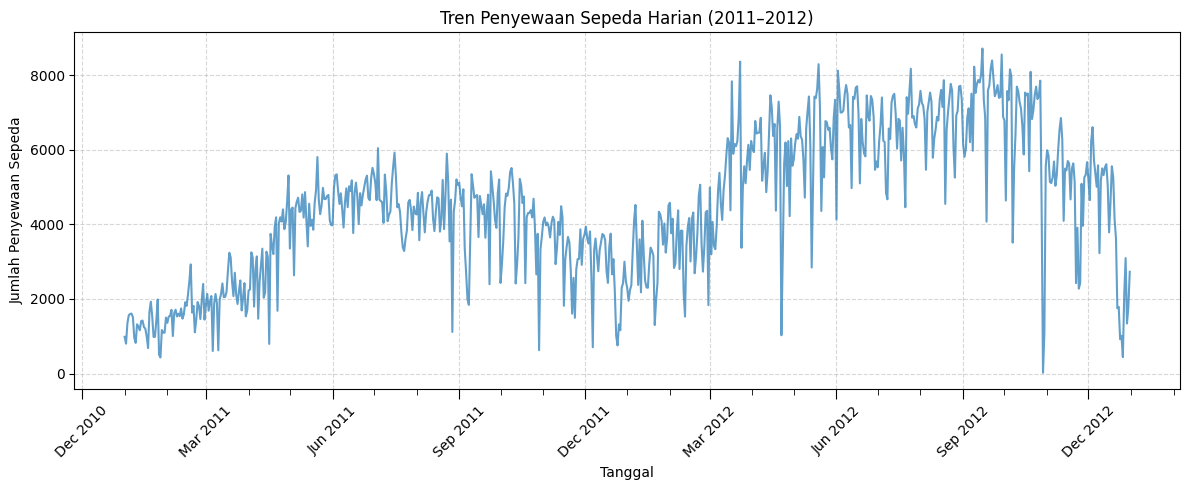

In [28]:
day['dteday'] = pd.to_datetime(day['dteday'], errors='coerce')

plt.figure(figsize=(12,5))
plt.plot(day['dteday'], day['cnt'], alpha=0.7)

ax = plt.gca()

# label tiap 3 bulan
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# garis kecil tiap bulan
ax.xaxis.set_minor_locator(mdates.MonthLocator())

ax.tick_params(axis='x', which='major', length=7)
ax.tick_params(axis='x', which='minor', length=4)

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan Sepeda')
plt.title('Tren Penyewaan Sepeda Harian (2011–2012)')

plt.tight_layout()
plt.show()

**Insight:**

Grafik garis (*line chart*) di atas menunjukkan pergerakan jumlah sepeda yang dirental setiap hari selama periode Januari 2011 hingga Desember 2012. Berdasarkan grafik tersebut, terlihat adanya pola musiman (*seasonality*) yang berulang setiap tahun. Artinya, tren penyewaan meningkat dan menurun pada periode tertentu secara konsisten.

Jumlah penyewaan sepeda cenderung berada pada tingkat yang lebih rendah pada awal dan akhir tahun, khususnya pada bulan Desember hingga Januari. Sebaliknya, jumlah penyewaan meningkat secara bertahap dan mencapai puncaknya pada pertengahan tahun. Hal ini mengindikasikan adanya pengaruh faktor musiman terhadap permintaan penyewaan sepeda.

Titik terendah dalam periode pengamatan terjadi pada akhir Oktober 2012, yang menunjukkan adanya penurunan ekstrem pada waktu tersebut.

### Explore the trend of bike rental count by months across years

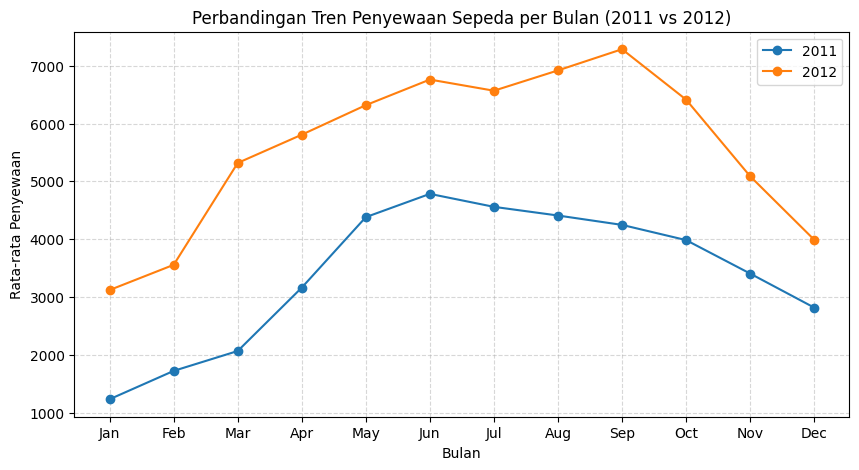

In [21]:
monthly = day.groupby(['yr', 'mnth'])['cnt'].mean().unstack(level=0)
monthly.columns = ['2011', '2012']

plt.figure(figsize=(10,5))

plt.plot(monthly.index, monthly['2011'], marker='o', label='2011')
plt.plot(monthly.index, monthly['2012'], marker='o', label='2012')

bulan = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.xticks(range(1,13), bulan)

plt.xlabel('Bulan')
plt.ylabel('Rata-rata Penyewaan')
plt.title('Perbandingan Tren Penyewaan Sepeda per Bulan (2011 vs 2012)')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Insight:**

*Double line chart* di atas menunjukkan perbandingan rata-rata jumlah sepeda yang dirental setiap bulan pada tahun 2011 (garis biru) dan 2012 (garis oranye). Secara umum, terlihat bahwa rata-rata penyewaan sepeda pada tahun 2012 cenderung lebih tinggi dibandingkan tahun 2011 di hampir seluruh bulan. Hal ini menunjukkan adanya peningkatan permintaan dari tahun ke tahun.

Selain itu, grafik menunjukkan pola musiman yang konsisten pada kedua tahun. Jumlah penyewaan berada pada titik terendah pada bulan Januari, kemudian meningkat secara bertahap hingga mencapai puncaknya pada pertengahan tahun, sebelum kembali menurun menjelang akhir tahun.

Pada tahun 2011, puncak penyewaan terjadi sekitar bulan Juni hingga Juli, sedangkan pada tahun 2012 puncak terjadi sedikit lebih lambat, yaitu sekitar bulan Agustus hingga September. Perbedaan waktu puncak ini menunjukkan adanya variasi kecil dalam pola musiman antartahun walaupun masih memiliki tren umumnya yang serupa.

### Explore the distribution of bike rental count by the weathers

/tmp/ipykernel_4171/2449437981.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


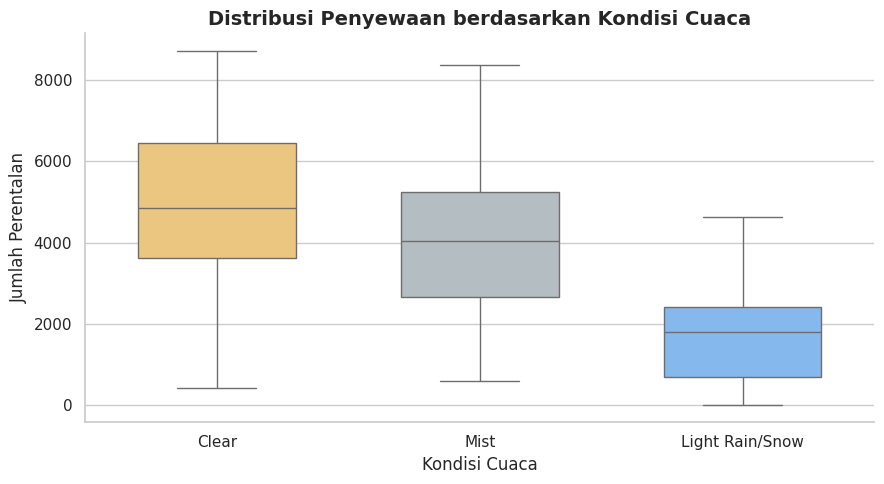

In [103]:
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

day['weather_label'] = day['weathersit'].map(weather_map)

existing_order = day['weather_label'].value_counts().index.tolist()

preferred_order = ['Clear', 'Mist', 'Light Rain/Snow', 'Heavy Rain/Snow']
order = [x for x in preferred_order if x in existing_order]

palette_map = {
    'Clear': '#FDCB6E',
    'Mist': '#B2BEC3',
    'Light Rain/Snow': '#74B9FF',
    'Heavy Rain/Snow': '#2D3436'
}

palette_weather = [palette_map[x] for x in order]

plt.figure(figsize=(9,5))

sns.boxplot(
    x='weather_label',
    y='cnt',
    data=day,
    order=order,
    palette=palette_weather,
    width=0.6,
    showfliers=False
)

plt.title('Distribusi Penyewaan berdasarkan Kondisi Cuaca',
          fontsize=14, fontweight='bold')

plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Perentalan')

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**

Boxplot di atas menunjukkan distribusi jumlah penyewaan sepeda berdasarkan kondisi cuaca. Terlihat bahwa kondisi cuaca cerah (*Clear*) memiliki median jumlah penyewaan tertinggi dibandingkan kondisi lainnya, diikuti oleh kondisi berkabut (*Mist*), sementara kondisi hujan ringan atau salju (*Light Rain/Snow*) memiliki median terendah.

Selain itu, distribusi pada kondisi *Clear* juga cenderung lebih tinggi secara keseluruhan serta memiliki rentang nilai yang luas hingga mencapai jumlah penyewaan maksimum tertinggi. Hal ini menunjukkan bahwa cuaca cerah tidak hanya meningkatkan rata-rata penyewaan, tetapi juga memungkinkan terjadinya jumlah penyewaan yang sangat tinggi pada hari-hari tertentu.

Sebaliknya, pada kondisi *Light Rain/Snow*, jumlah penyewaan relatif lebih rendah dan lebih terkonsentrasi pada nilai yang kecil. Hal ini menandakan bahwa kondisi cuaca buruk secara signifikan menurunkan minat masyarakat untuk menyewa sepeda.

Sementara itu, kondisi *Mist* berada di antara keduanya. Ini menunjukkan bahwa meskipun tidak sebaik cuaca cerah, penyewaan sepeda masih cukup tinggi dibandingkan saat terjadi hujan atau salju.

### Explore the mean of bike rental count by hours in a day

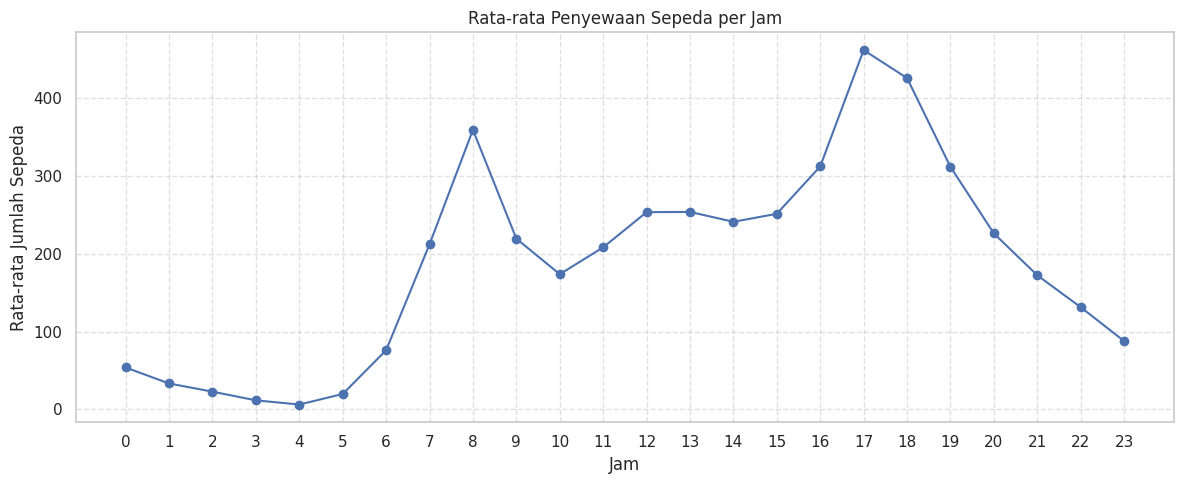

In [100]:
hourly_avg = hour.groupby('hr')['cnt'].mean()

plt.figure(figsize=(12,5))

hourly_avg.plot(marker='o')

plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Sepeda')
plt.title('Rata-rata Penyewaan Sepeda per Jam')

plt.tight_layout()
plt.show()

**Insight:**

*Line chart* i atas menunjukkan rata-rata jumlah sepeda yang dirental berdasarkan jam dalam sehari. Terlihat bahwa jumlah penyewaan berada pada tingkat terendah pada dini hari, yaitu sekitar pukul 00.00 hingga 05.00 dengan titik minimum terjadi pada pukul 04.00. Hal ini menunjukkan bahwa aktivitas perentalan sepeda sangat rendah pada waktu tersebut.

Selanjutnya, jumlah penyewaan mulai meningkat pada pagi hari dan mencapai puncak pertama sekitar pukul 08.00. Setelah itu, penyewaan cenderung menurun pada siang hari sebelum kembali meningkat dan mencapai puncak tertinggi pada sore hari, yaitu sekitar pukul 17.00 hingga 18.00.

Pola ini mengindikasikan bahwa penyewaan sepeda banyak digunakan pada jam sibuk (*rush hours*), khususnya pada waktu berangkat dan pulang kerja. Ini juga mencerminkan penggunaan sepeda sebagai sarana transportasi harian.

###  Explore the correlations between numeric features

<Axes: >

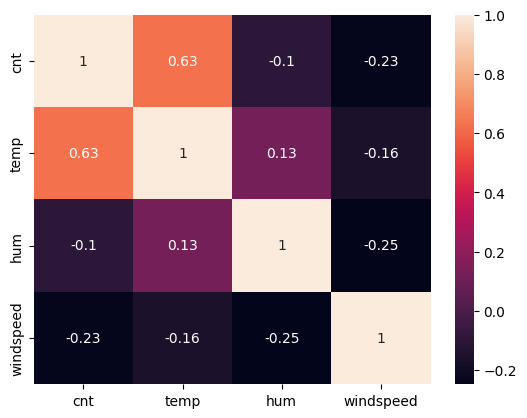

In [18]:
sns.heatmap(day[['cnt','temp','hum','windspeed']].corr(), annot=True)

**Insight:**

*Heatmap* di atas menunjukkan pola korelasi antara jumlah sepeda yang dirental (`cnt`) tdengan beberapa variabel cuaca, yaitu suhu (`temp`), kelembapan (`humidity`), dan kecepatan angin (`windspeed`).

Berdasarkan hasil tersebut, variabel suhu (`temp`) memiliki korelasi positif paling kuat terhadap jumlah penyewaan sepeda dengan nilai sebesar 0,63. Hal ini menunjukkan bahwa peningkatan suhu cenderung diikuti oleh peningkatan jumlah penyewaan sepeda. Meski begitu, hubungan yang terbentuk berada pada tingkat moderat.

Sebaliknya, kelembapan (`hum`) dan kecepatan angin (`windspeed`) memiliki korelasi negatif yang lemah terhadap jumlah penyewaan, masing-masing sebesar -0,10 dan -0,23. Hal ini menunjukkan bahwa peningkatan kelembapan dan kecepatan angin cenderung diikuti oleh penurunan jumlah penyewaan dengan pengaruh yang relatif kecil dibandingkan suhu.

Secara keseluruhan, dapat disimpulkan bahwa suhu merupakan faktor cuaca yang paling berpengaruh terhadap jumlah penyewaan sepeda dibandingkan variabel cuaca lainnya.

### Explore the relationship between bike rental count and temperature

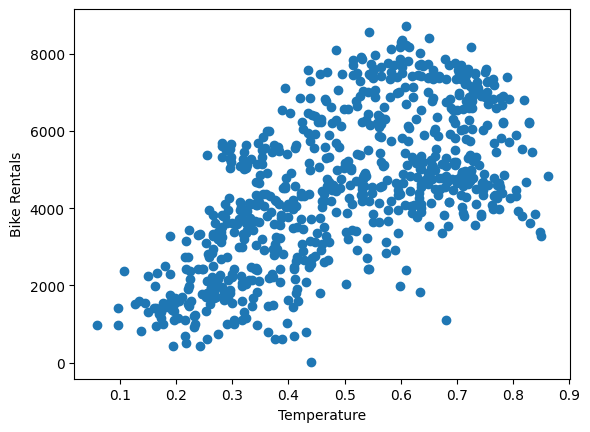

In [12]:
plt.scatter(day['temp'], day['cnt'])
plt.xlabel('Temperature')
plt.ylabel('Bike Rentals')
plt.show()

**Insight:**

*Scatterplot* di atas menunjukkan hubungan antara suhu (*Temperature* atau `temp`) dan jumlah penyewaan sepeda (*Bike Rentals* atau `cnt`). Terlihat adanya kecenderungan hubungan positif yang berarti bahwa jumlah penyewaan sepeda meningkat seiring dengan kenaikan suhu.

Namun, hubungan tersebut tidak sepenuhnya linier. Pada rentang suhu rendah hingga sedang, peningkatan suhu diikuti oleh kenaikan jumlah penyewaan yang cukup signifikan. Akan tetapi, pada suhu yang lebih tinggi, peningkatan jumlah penyewaan mulai melambat dan cenderung stabil, bahkan pada beberapa titik mengalami penurunan.

Selain itu, terlihat adanya penyebaran data yang cukup luas pada suhu menengah hingga tinggi. Hal ini menunjukkan bahwa terdapat faktor lain selain suhu yang turut memengaruhi jumlah penyewaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren penyewaan sepeda secara harian selama periode 2011–2012?

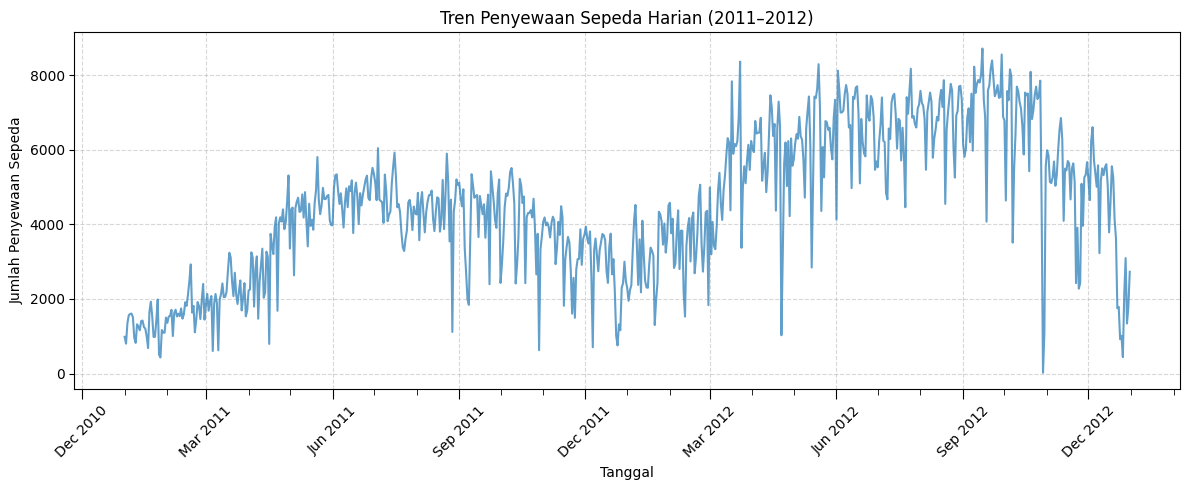

In [29]:
day['dteday'] = pd.to_datetime(day['dteday'], errors='coerce')

plt.figure(figsize=(12,5))
plt.plot(day['dteday'], day['cnt'], alpha=0.7)

ax = plt.gca()

# label tiap 3 bulan
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# garis kecil tiap bulan
ax.xaxis.set_minor_locator(mdates.MonthLocator())

ax.tick_params(axis='x', which='major', length=7)
ax.tick_params(axis='x', which='minor', length=4)

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan Sepeda')
plt.title('Tren Penyewaan Sepeda Harian (2011–2012)')

plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan visualisasi tren harian, jumlah penyewaan sepeda menunjukkan pola yang berfluktuasi dengan kecenderungan meningkat dari tahun 2011 ke 2012. Meskipun terdapat variasi harian yang cukup tinggi, secara umum terlihat bahwa tingkat penyewaan pada tahun 2012 berada pada level yang lebih tinggi dibandingkan tahun sebelumnya.

Selain itu, pola kenaikan dan penurunan yang berulang setiap tahun mengindikasikan adanya pengaruh musiman terhadap penyewaan sepeda. Hal ini menunjukkan bahwa permintaan tidak bersifat acak, melainkan mengikuti pola tertentu sepanjang waktu.

### Pertanyaan 2: Pada bulan apa terjadi puncak penyewaan sepeda dan bagaimana pola musiman selama periode 2011–2012?

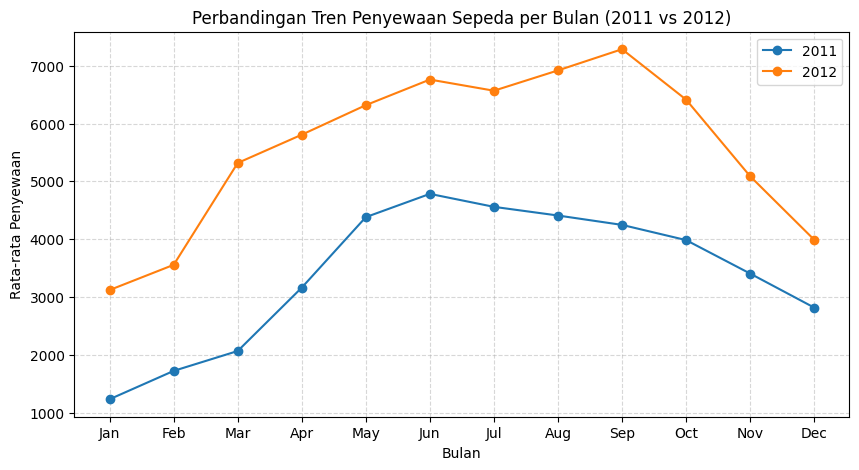

In [30]:
monthly = day.groupby(['yr', 'mnth'])['cnt'].mean().unstack(level=0)
monthly.columns = ['2011', '2012']

plt.figure(figsize=(10,5))

plt.plot(monthly.index, monthly['2011'], marker='o', label='2011')
plt.plot(monthly.index, monthly['2012'], marker='o', label='2012')

bulan = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.xticks(range(1,13), bulan)

plt.xlabel('Bulan')
plt.ylabel('Rata-rata Penyewaan')
plt.title('Perbandingan Tren Penyewaan Sepeda per Bulan (2011 vs 2012)')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Insight:**

Berdasarkan analisis bulanan, puncak penyewaan sepeda terjadi pada pertengahan hingga akhir tahun, khususnya pada bulan Juni hingga September. Sebaliknya, jumlah penyewaan terendah terjadi pada awal tahun, yaitu sekitar bulan Januari.

Pola ini konsisten pada kedua tahun yang diamati sehingga menunjukkan adanya pola musiman yang kuat. Selain itu, tingkat penyewaan pada tahun 2012 cenderung lebih tinggi dibandingkan tahun 2011 di hampir seluruh bulan. Hal ini menunjukkan adanya pertumbuhan permintaan dari tahun ke tahun.

### Pertanyaan 3: Bagaimana perbedaan pola penyewaan pada waktu tertentu dalam sehari?

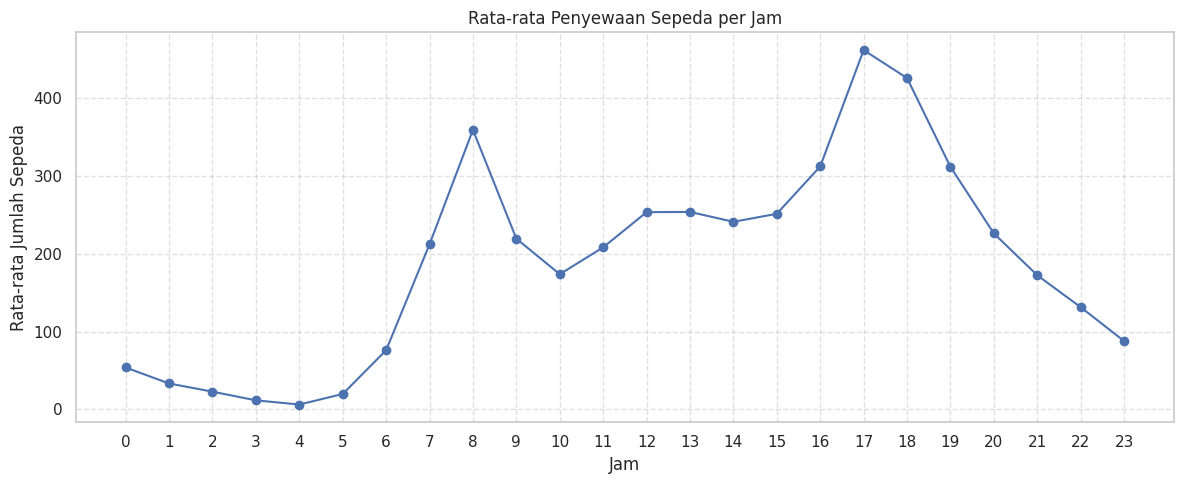

In [104]:
plt.figure(figsize=(12,5))

hourly_avg.plot(marker='o')

plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Sepeda')
plt.title('Rata-rata Penyewaan Sepeda per Jam')

plt.tight_layout()
plt.show()

**Insight:**

Pola penyewaan sepeda dalam sehari menunjukkan dua puncak utama, yaitu pada pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00–18.00. Sementara itu, jumlah penyewaan berada pada titik terendah pada dini hari, khususnya antara pukul 00.00 hingga 05.00.

Pola ini mengindikasikan bahwa sepeda banyak digunakan pada jam sibuk (*rush hours*), terutama untuk aktivitas komuter seperti perjalanan menuju dan dari tempat kerja. Dengan demikian, waktu menjadi faktor penting dalam menentukan pola permintaan penyewaan sepeda.

### Pertanyaan 4: Berapa perbedaan rata-rata jumlah penyewaan sepeda pada setiap kondisi cuaca dan faktor lingkungan (suhu, kelembapan, dan kecepatan angin) selama periode 2011–2012?

/tmp/ipykernel_4171/519375420.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


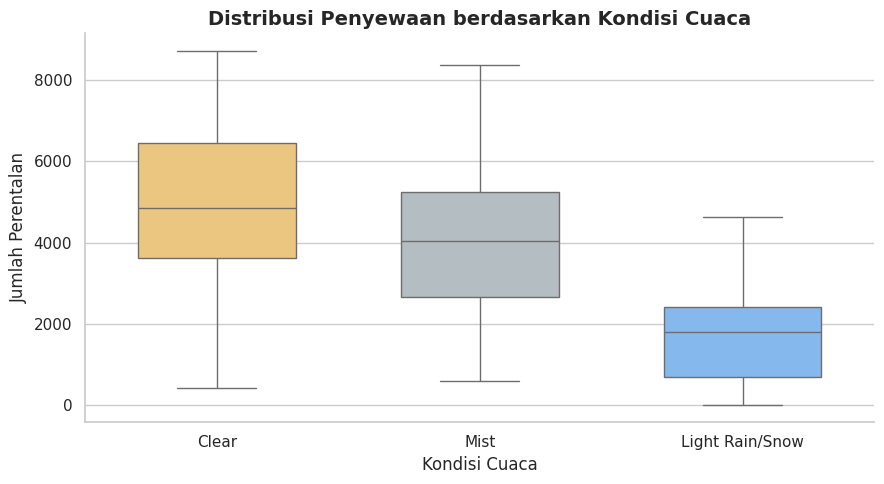

In [102]:
existing_order = day['weather_label'].value_counts().index.tolist()

preferred_order = ['Clear', 'Mist', 'Light Rain/Snow', 'Heavy Rain/Snow']
order = [x for x in preferred_order if x in existing_order]

palette_map = {
    'Clear': '#FDCB6E',
    'Mist': '#B2BEC3',
    'Light Rain/Snow': '#74B9FF',
    'Heavy Rain/Snow': '#2D3436'
}

palette_weather = [palette_map[x] for x in order]

plt.figure(figsize=(9,5))

sns.boxplot(
    x='weather_label',
    y='cnt',
    data=day,
    order=order,
    palette=palette_weather,
    width=0.6,
    showfliers=False
)

plt.title('Distribusi Penyewaan berdasarkan Kondisi Cuaca',
          fontsize=14, fontweight='bold')

plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Perentalan')

sns.despine()
plt.tight_layout()
plt.show()

<Axes: >

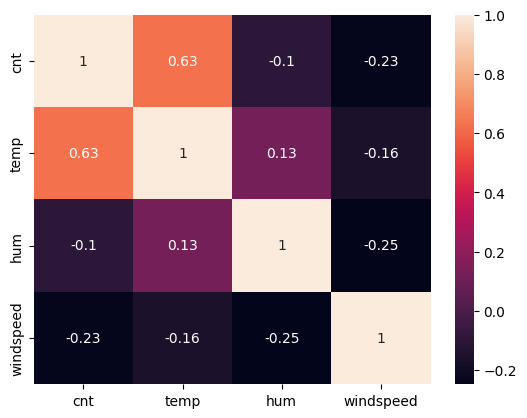

In [33]:
sns.heatmap(day[['cnt','temp','hum','windspeed']].corr(), annot=True)

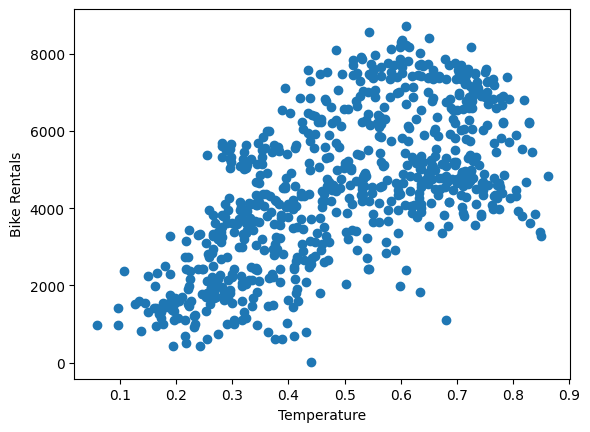

In [34]:
plt.scatter(day['temp'], day['cnt'])
plt.xlabel('Temperature')
plt.ylabel('Bike Rentals')
plt.show()

**Insight:**

Analisis menunjukkan bahwa kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Pada kondisi cuaca cerah (*Clear*), jumlah penyewaan memiliki nilai rata-rata dan median yang paling tinggi. Sebaliknya, pada kondisi hujan ringan atau salju (*Light Rain/Snow*), jumlah penyewaan cenderung lebih rendah.

Selain itu, suhu (*temperature*) juga menunjukkan hubungan positif dengan jumlah penyewaan, di mana peningkatan suhu cenderung diikuti oleh peningkatan jumlah penyewaan sepeda. Namun, hubungan ini tidak sepenuhnya linier karena pada suhu yang lebih tinggi, peningkatan jumlah penyewaan mulai melambat.

Secara keseluruhan, dapat disimpulkan bahwa kondisi cuaca yang lebih baik dan suhu yang lebih hangat cenderung mendorong peningkatan aktivitas penyewaan sepeda.

## Analisis Lanjutan (*Clustering*)

Sebelum melakukan analisis lanjutan berupa *manual grouping* dan *binning*, disajikan statistik deskriptif untuk setiap variabel numerik untuk mengetahui rentang nilai yang akan di-*grouping* atau di-*binning*.

In [37]:
day.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,datetime
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837,2012-01-01 00:00:00
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,2011-01-01 00:00:00
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000,2011-07-02 12:00:00
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000,2012-01-01 00:00:00
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,2012-07-01 12:00:00
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,2012-12-31 00:00:00
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452,NaN


In [38]:
hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,datetime
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088,2012-01-02 15:41:22.858622464
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2011-01-01 00:00:00
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,2011-07-04 22:30:00
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,2012-01-02 21:00:00
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,2012-07-02 06:30:00
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000,2012-12-31 23:00:00
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599,NaN


#### Manual Grouping

##### Grouping hours

Waktu pada data dikelompokkan menjadi 4 kategori, yaitu Dini Hari, Pagi, Siang, dan Malam.

In [39]:
def time_category(hour):
    if 0 <= hour < 6:
        return 'Dini Hari'
    elif 6 <= hour < 12:
        return 'Pagi'
    elif 12 <= hour < 18:
        return 'Siang'
    else:
        return 'Malam'

hour['time_category'] = hour['hr'].apply(time_category)

time_group = hour.groupby('time_category')['cnt'].mean()
print(time_group)

time_category
Dini Hari     24.908559
Malam        225.757555
Pagi         208.100688
Siang        295.483886
Name: cnt, dtype: float64


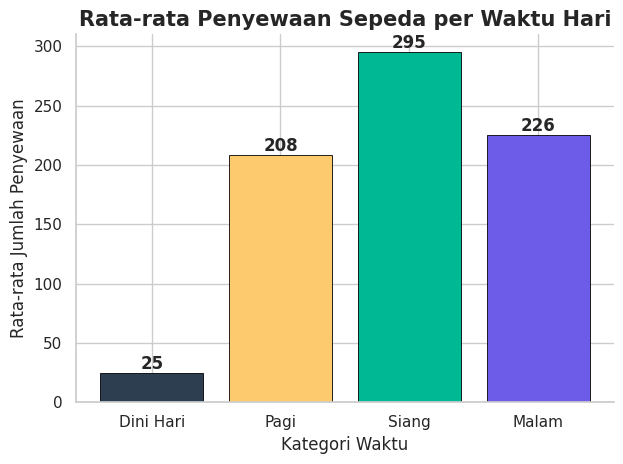

In [61]:
sns.set_theme(style="whitegrid")

order = ['Dini Hari', 'Pagi', 'Siang', 'Malam']

time_group = hour.groupby('time_category')['cnt'].mean().reindex(order)

colors = [
    '#2C3E50',  # Dini Hari: dark navy
    '#FDCB6E',  # Pagi: warm soft yellow
    '#00B894',  # Siang: fresh bright green
    '#6C5CE7'   # Malam: deep purple
]

bars = plt.bar(
    time_group.index,
    time_group.values,
    color=colors,
    edgecolor='black',
    linewidth=0.6
)

plt.title('Rata-rata Penyewaan Sepeda per Waktu Hari',
          fontsize=15, fontweight='bold')

plt.xlabel('Kategori Waktu', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**

Grafik batang menunjukkan rata-rata jumlah penyewaan sepeda perhari berdasarkan kategori waktu yang telah dikelompokkan. Terlihat bahwa aktivitas penyewaan terendah terjadi pada dini hari, lalu meningkat pada pagi hari dan mencapai puncaknya pada siang hari, sebelum kembali menurun pada malam hari. Hal ini menunjukkan pola penggunaan sepeda yang mengikuti aktivitas harian masyarakat dengan intensitas tertinggi pada jam-jam produktif.

##### Grouping casual ratio

Pengelompokan dilakukan berdasarkan rasio pengguna kasual terhadap total penyewaan `(casual_ratio = casual / cnt)` yang kemudian diklasifikasikan menjadi tiga kategori: *Mostly Registered*, *Balanced*, dan *Mostly Casual*.

In [43]:
day['casual_ratio'] = day['casual'] / day['cnt']

bins = [0, 0.3, 0.7, 1]
labels = ['Mostly Registered', 'Balanced', 'Mostly Casual']

day['user_segment'] = pd.cut(day['casual_ratio'], bins=bins, labels=labels)

In [57]:
user_group = day.groupby('user_segment')['cnt'].sum()
print(user_group)

user_segment
Mostly Registered    2599632
Balanced              693047
Mostly Casual              0
Name: cnt, dtype: int64


/tmp/ipykernel_4171/1177641064.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_group = day.groupby('user_segment')['cnt'].sum()


/tmp/ipykernel_4171/1308807513.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_group = day.groupby('user_segment')['cnt'].sum()


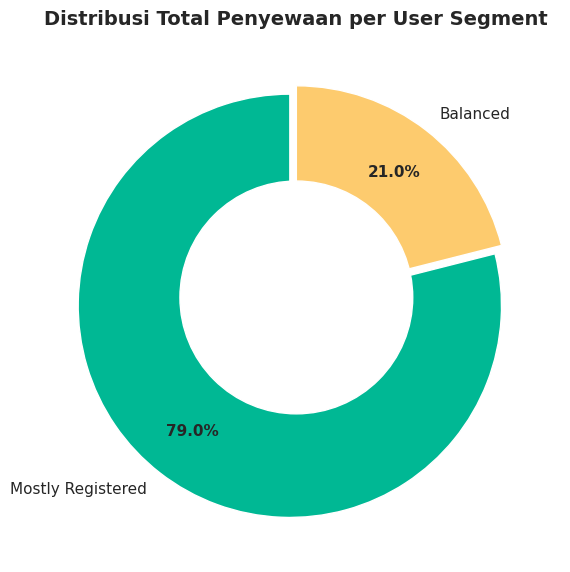

In [62]:
user_group = day.groupby('user_segment')['cnt'].sum()
user_group_filtered = user_group[user_group > 0]

colors = ['#00B894', '#FDCB6E', '#6C5CE7']

explode = [0.05 if v == user_group_filtered.max() else 0
           for v in user_group_filtered.values]

plt.figure(figsize=(6,6))

wedges, texts, autotexts = plt.pie(
    user_group_filtered,
    labels=user_group_filtered.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    pctdistance=0.75,
    textprops={'fontsize': 11}
)

# donut chart
centre_circle = plt.Circle((0,0),0.55,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# styling percentage text
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

plt.title('Distribusi Total Penyewaan per User Segment',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**

*Donut chart* menunjukkan bahwa sebagian besar observasi termasuk dalam kategori *Mostly Registered* dengan proporsi sekitar 79%. Sementara itu, kategori *Mostly Casual* tidak muncul dalam data karena tidak terdapat observasi yang memenuhi kriteria tersebut (rasio sangat tinggi pada pengguna casual tidak terjadi dalam periode pengamatan). Hal ini menunjukkan bahwa sistem penyewaan sepeda didominasi oleh pengguna terdaftar dibandingkan pengguna kasual.

#### Binning

##### Temperature

Temperatur (suhu) dikelompokkan menjadi tiga kategori berdasarkan interval nilai yang telah ditentukan, yaitu *Cold*, *Mild*, dan *Warm*.

In [40]:
# Temperature

bins = [0, 0.337, 0.655, 1]
labels = ['Cold', 'Mild', 'Warm']

day['temp_cat'] = pd.cut(day['temp'], bins=bins, labels=labels)

/tmp/ipykernel_4171/1844479118.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


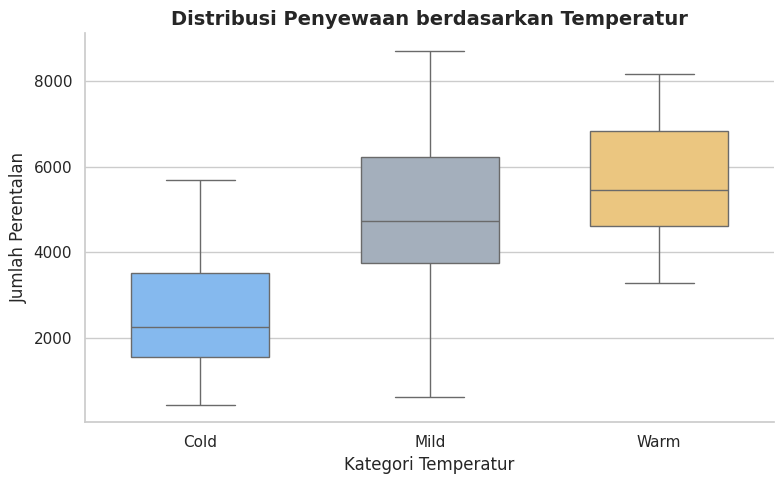

In [95]:
sns.set_theme(style="whitegrid")

palette_temp = ['#74B9FF', '#A0AEC0', '#FDCB6E']

plt.figure(figsize=(8,5))

sns.boxplot(
    x='temp_cat',
    y='cnt',
    data=day,
    order=['Cold', 'Mild', 'Warm'],
    palette=palette_temp,
    width=0.6,
    showfliers=False
)

plt.title('Distribusi Penyewaan berdasarkan Temperatur',
          fontsize=14, fontweight='bold')

plt.xlabel('Kategori Temperatur')
plt.ylabel('Jumlah Perentalan')

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan boxplot, terlihat bahwa median jumlah penyewaan tertinggi terdapat pada kategori *Warm*, diikuti oleh *Mild*, dan terendah pada *Cold*. Selain itu, kategori *Mild* menunjukkan sebaran (IQR dan *whisker*) yang paling luas dibandingkan kategori lainnya. Ini menunjukkan bahwa variasi jumlah penyewaan yang lebih tinggi pada kondisi temperatur sedang.

##### Humidity

*Humidity* atau Kelembapan dibagi menjadi tiga kategori, yaitu *Low*, *Medium*, dan *High* berdasarkan interval nilai yang telah ditentukan.

In [41]:
# Humidity

bins = [0, 0.5, 0.7, 1]
labels = ['Low', 'Medium', 'High']

day['hum_cat'] = pd.cut(day['hum'], bins=bins, labels=labels)

/tmp/ipykernel_4171/503324211.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


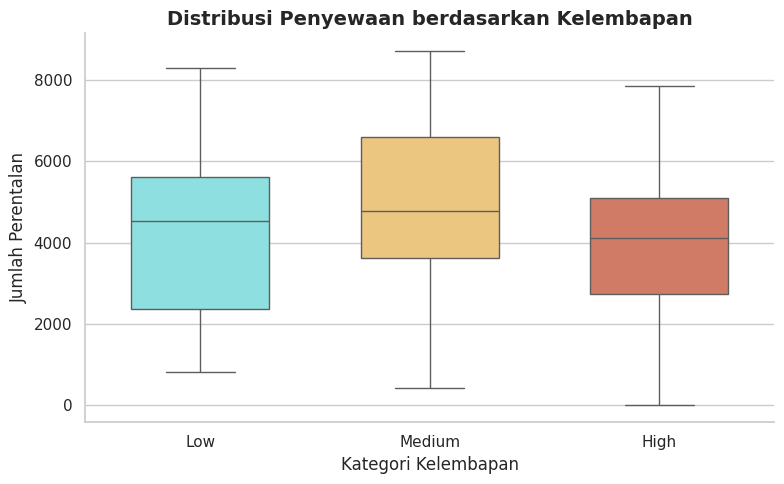

In [94]:
sns.set_theme(style="whitegrid")

palette_hum = ['#81ECEC', '#FDCB6E', '#E17055']

plt.figure(figsize=(8,5))

sns.boxplot(
    x='hum_cat',
    y='cnt',
    data=day,
    order=['Low', 'Medium', 'High'],
    palette=palette_hum,
    width=0.6,
    showfliers=False
)

plt.title('Distribusi Penyewaan berdasarkan Kelembapan',
          fontsize=14, fontweight='bold')

plt.xlabel('Kategori Kelembapan')
plt.ylabel('Jumlah Perentalan')

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**

Hasil boxplot menunjukkan bahwa median jumlah penyewaan tertinggi terdapat pada kategori *Medium*, diikuti oleh *Low*, dan terendah pada *High*. Meskipun demikian, perbedaan sebaran antar kategori relatif tidak terlalu jauh. Namun, kategori *Medium* menunjukkan variasi yang sedikit lebih besar dibandingkan kategori lainnya berdasarkan panjang *whisker*.

##### Wind Speed

Kecepatan angin atau *wind speed* dikategorikan menjadi tiga kelompok, yaitu *Low*, *Medium*, dan *High* berdasarkan interval yang telah ditentukan.

In [42]:
# Wind Speed

bins = [0, 0.15, 0.25, 0.6]
labels = ['Low', 'Medium', 'High']

day['wind_cat'] = pd.cut(day['windspeed'], bins=bins, labels=labels)

/tmp/ipykernel_4171/4207233776.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


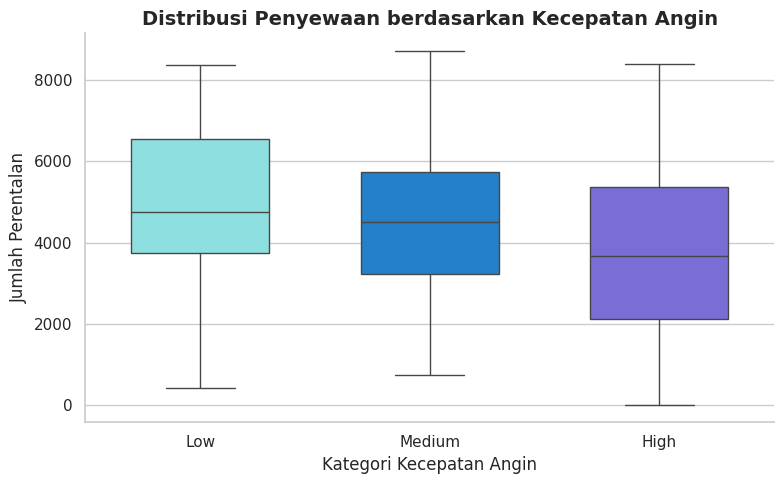

In [96]:
sns.set_theme(style="whitegrid")

palette_wind = ['#81ECEC', '#0984E3', '#6C5CE7']

plt.figure(figsize=(8,5))

sns.boxplot(
    x='wind_cat',
    y='cnt',
    data=day,
    order=['Low', 'Medium', 'High'],
    palette=palette_wind,
    width=0.6,
    showfliers=False
)

plt.title('Distribusi Penyewaan berdasarkan Kecepatan Angin',
          fontsize=14, fontweight='bold')

plt.xlabel('Kategori Kecepatan Angin')
plt.ylabel('Jumlah Perentalan')

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan boxplot, median jumlah penyewaan tertinggi terdapat pada kategori *Low*, diikuti oleh *Medium*, dan terendah pada *High*. Namun, perbedaan antar kategori tidak terlalu signifikan, baik dari sisi median maupun sebaran data. Ini menunjukkan bahwa kecepatan angin memiliki pengaruh yang relatif lebih kecil dibandingkan variabel lingkungan lainnya.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Secara keseluruhan, jumlah penyewaan sepeda menunjukkan tren yang meningkat dari tahun 2011 ke 2012. Meskipun terdapat fluktuasi harian yang cukup tinggi, pola umum menunjukkan bahwa tingkat penggunaan sepeda pada tahun 2012 lebih tinggi dibandingkan tahun sebelumnya. Hal ini menunjukkan adanya pertumbuhan permintaan layanan penyewaan sepeda dari waktu ke waktu, bukan sekadar variasi acak.
- **Conclusion pertanyaan 2:** Analisis bulanan menunjukkan adanya pola musiman yang konsisten pada periode 2011–2012. Penyewaan sepeda mencapai puncaknya pada bulan-bulan pertengahan hingga akhir tahun (sekitar Juni–September), sementara periode awal tahun (Januari–Februari) menunjukkan tingkat penyewaan yang paling rendah. Pola ini menunjukkan bahwa faktor musim dan kondisi lingkungan berperan penting dalam memengaruhi tingkat permintaan.
- **Conclusion pertanyaan 3:** Penyewaan sepeda menunjukkan pola harian yang jelas dengan dua puncak utama, yaitu pada pagi hari (sekitar pukul 08.00) dan sore hari (sekitar pukul 17.00–18.00). Sebaliknya, periode dini hari (00.00–05.00) menunjukkan tingkat penyewaan terendah. Pola ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas komuter, terutama pada jam kerja, sehingga waktu merupakan faktor penting dalam menentukan permintaan.
- **Conclusion pertanyaan 4:** Hasil analisis menunjukkan bahwa kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Kondisi cerah (*Clear*) menghasilkan rata-rata penyewaan tertinggi, sementara kondisi hujan atau salju ringan menyebabkan penurunan aktivitas. Selain itu, suhu memiliki hubungan positif terhadap jumlah penyewaan dengan peningkatan suhu yang cenderung meningkatkan permintaan hingga titik tertentu. Sebaliknya, kelembapan dan kecepatan angin menunjukkan pengaruh yang relatif lebih lemah dibandingkan suhu dan kondisi cuaca.

**Rekomendasi Action Item:**
- Perusahaan perlu meningkatkan ketersediaan sepeda pada jam puncak, yaitu pagi (07.00–09.00) dan sore (17.00–19.00) karena pada periode ini terjadi lonjakan permintaan yang signifikan. Strategi redistribusi sepeda antar stasiun juga diperlukan untuk menghindari ketidakseimbangan pasokan.
- Karena permintaan lebih tinggi pada pertengahan hingga akhir tahun, perusahaan dapat menyesuaikan strategi operasional seperti penambahan armada, promosi, atau harga dinamis pada periode tersebut. Sebaliknya, pada awal tahun yang cenderung sepi, dapat diterapkan strategi promosi untuk menjaga stabilitas penggunaan.
- Karena cuaca sangat cukup permintaan, sistem operasional dapat mengadopsi pendekatan prediktif berbasis *weather forecast*. Pada kondisi cuaca buruk, redistribusi atau pengurangan *supply* sementara dapat dilakukan untuk efisiensi operasional.
- Pola dua puncak harian menunjukkan dominasi pengguna komuter. Oleh karena itu, strategi layanan dapat difokuskan pada integrasi dengan transportasi publik, seperti penyediaan *bike station* dekat stasiun atau area perkantoran.
- Model prediktif dapat dibangun menggunakan variabel waktu dan cuaca sebagai fitur utama untuk memprediksi permintaan harian. Hal ini dapat membantu optimasi stok sepeda dan meningkatkan efisiensi operasional.